## Plot AIC and psuedo.r.squared across segmentation interval

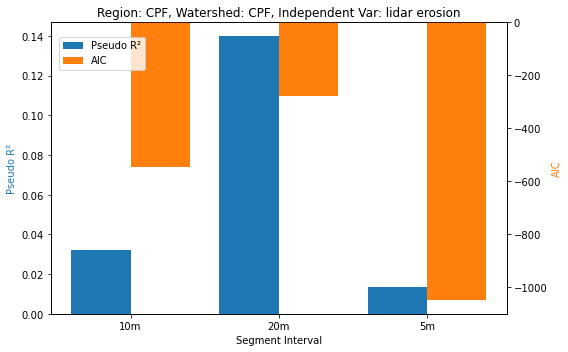

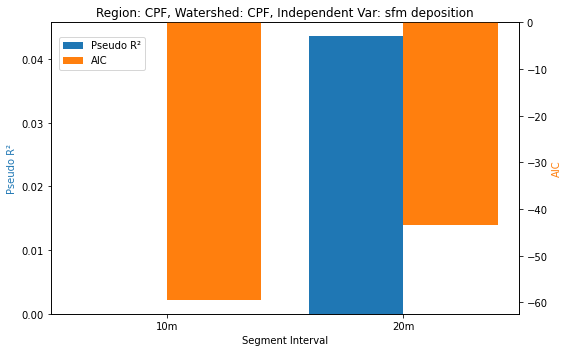

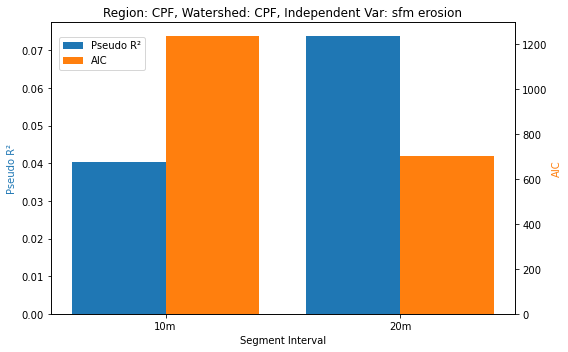

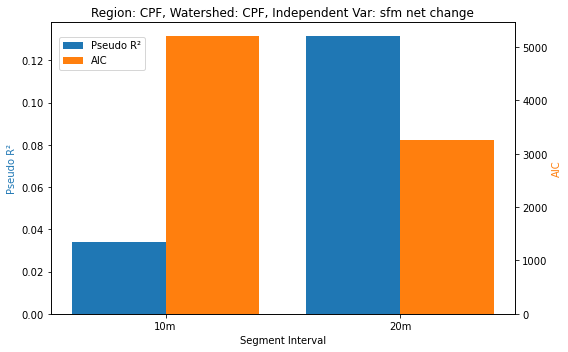

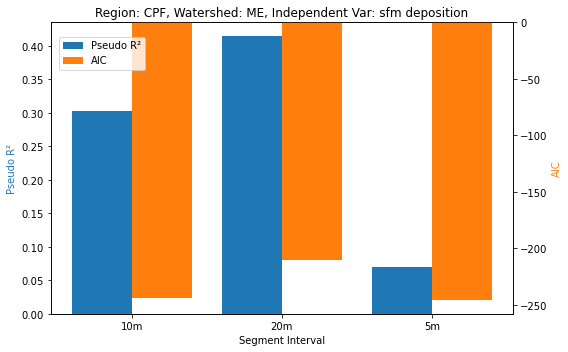

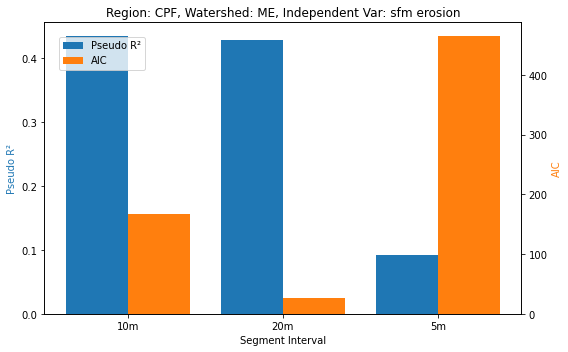

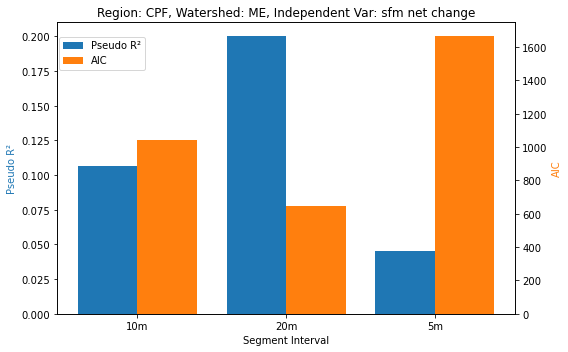

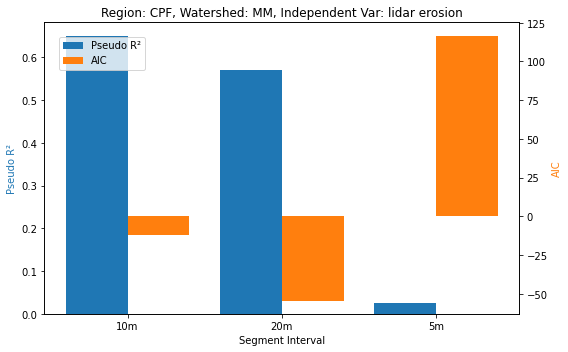

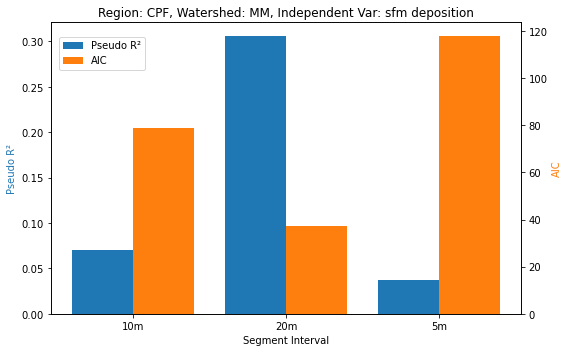

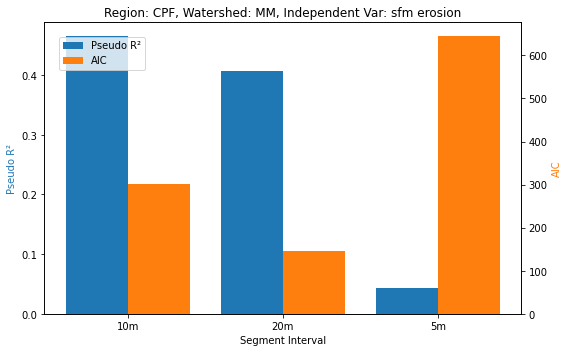

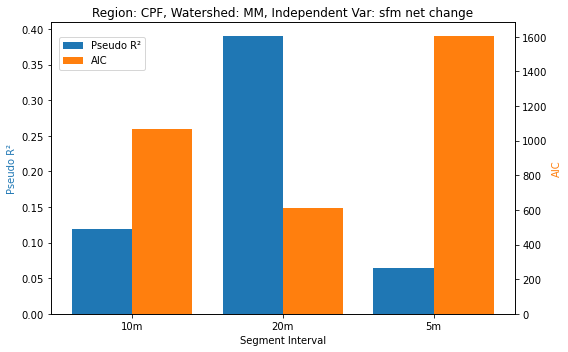

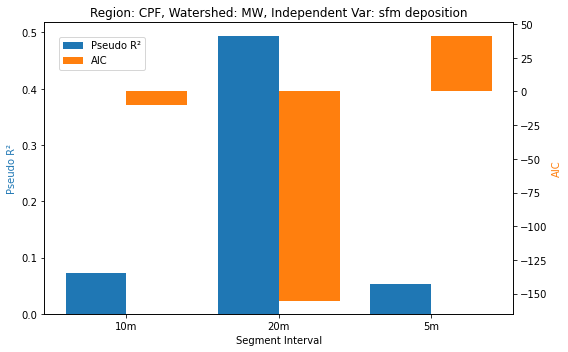

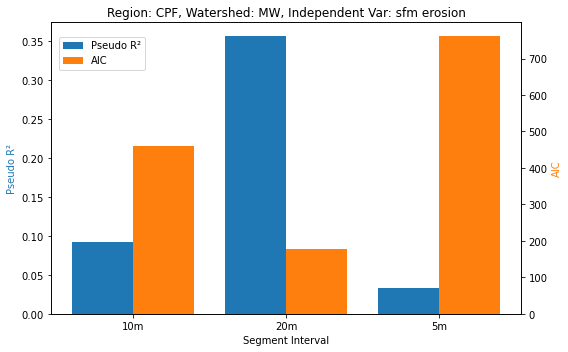

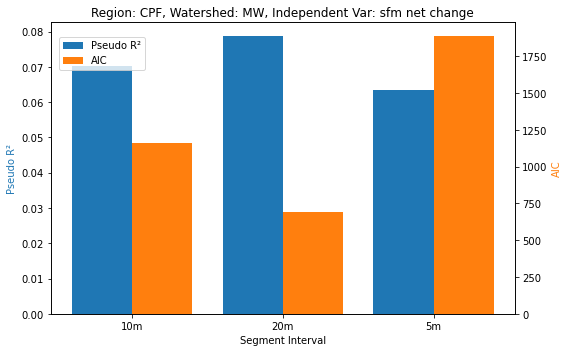

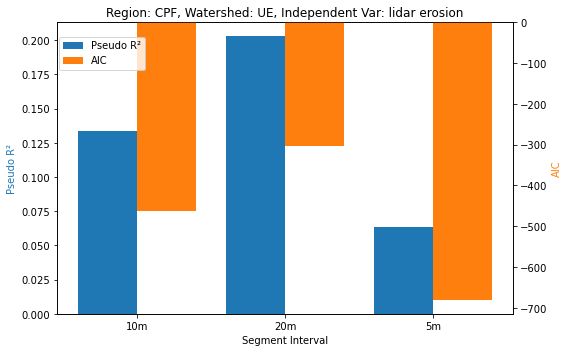

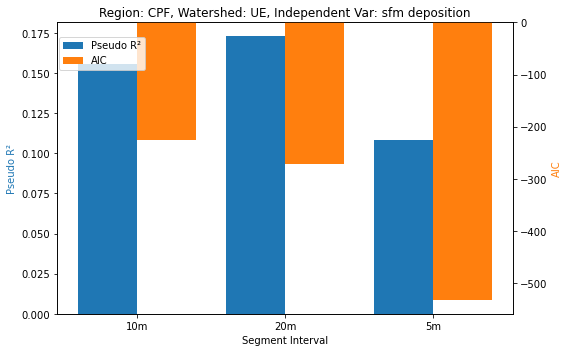

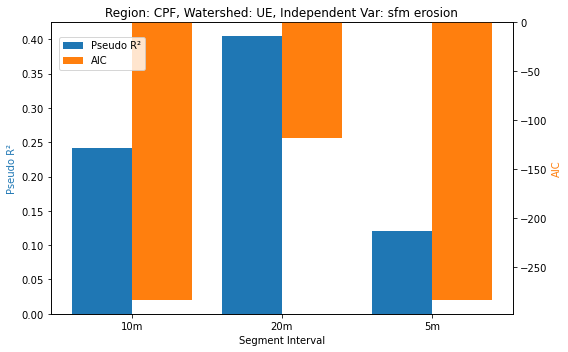

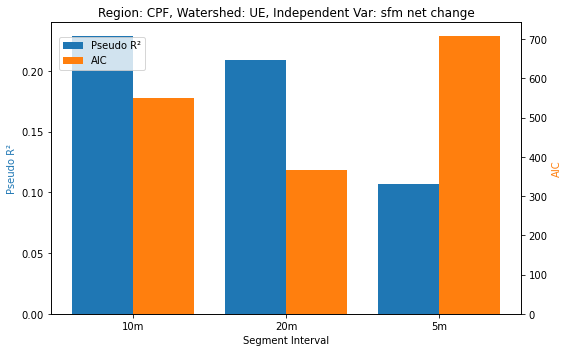

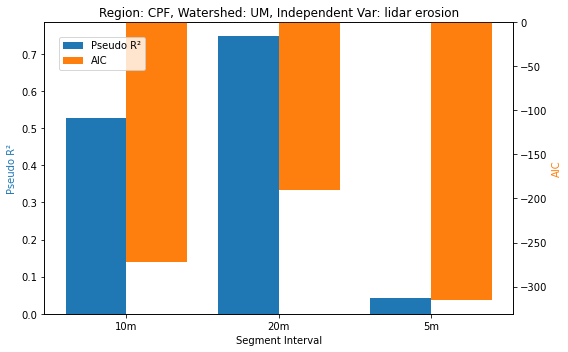

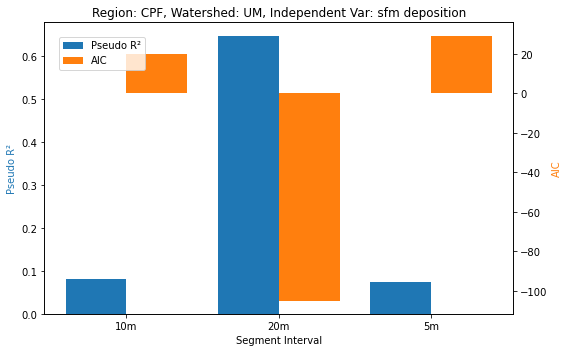

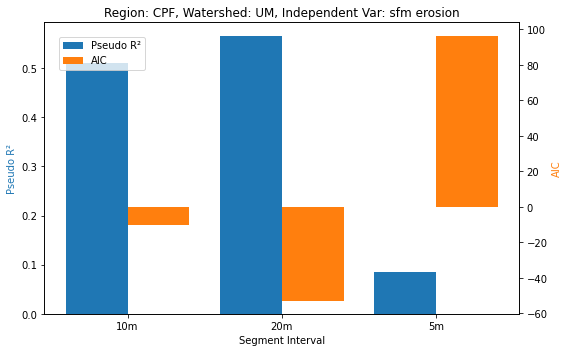

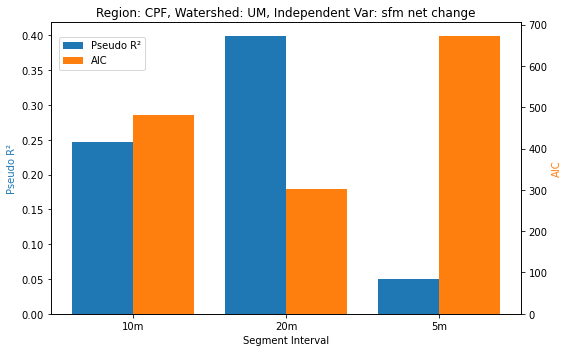

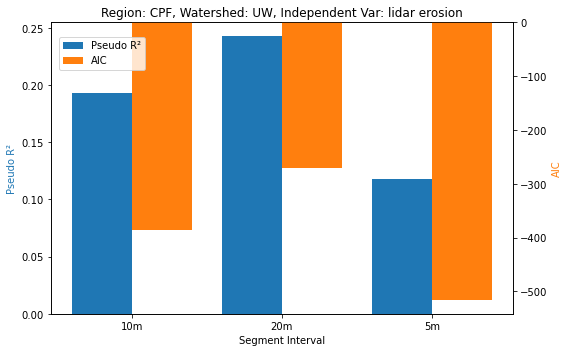

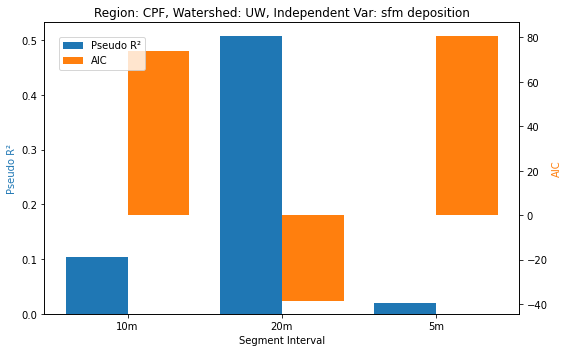

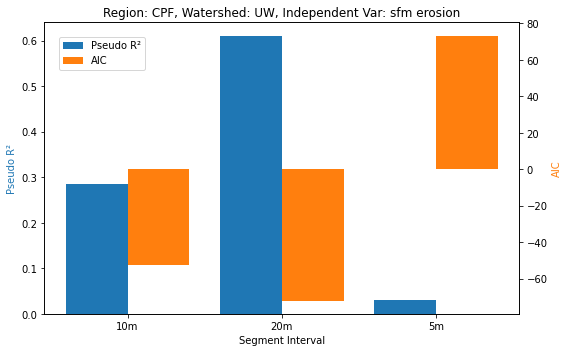

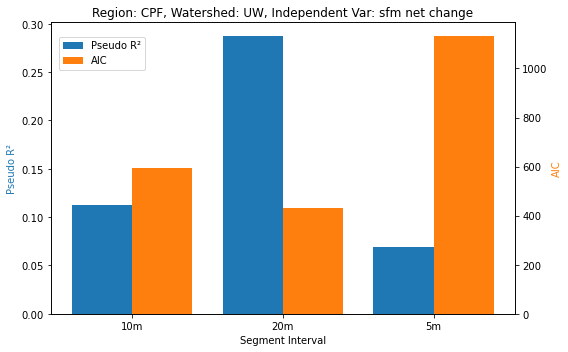

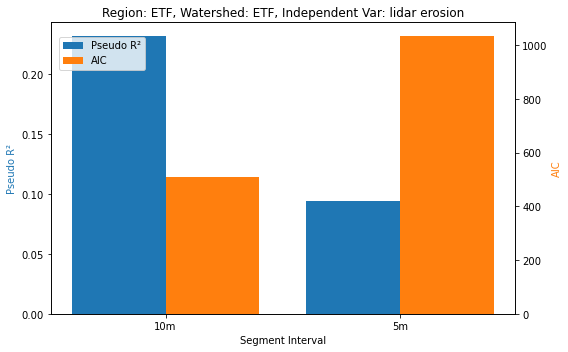

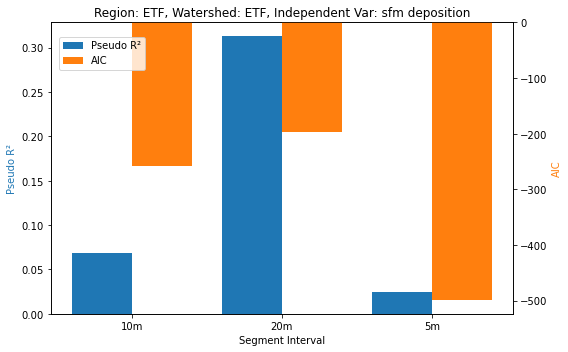

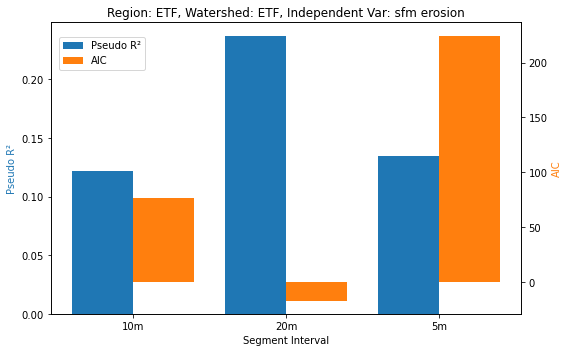

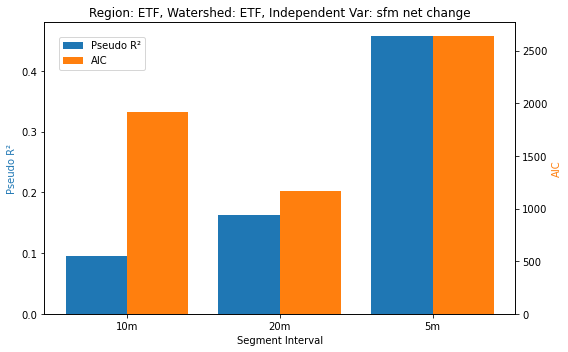

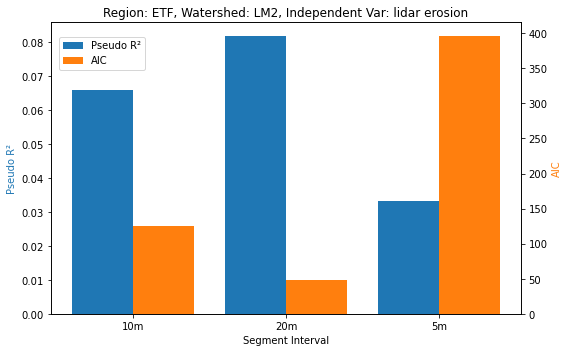

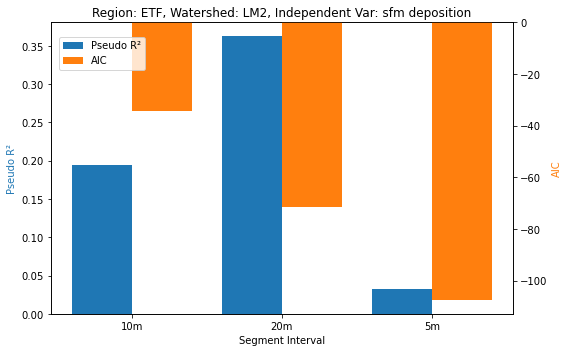

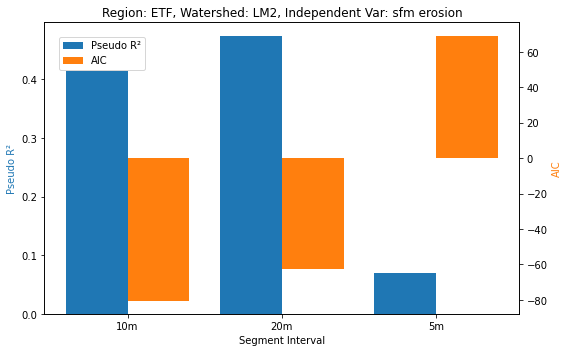

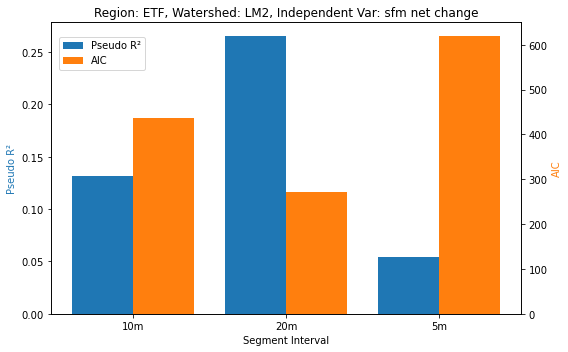

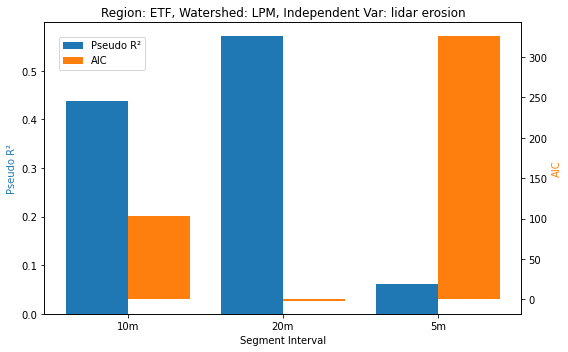

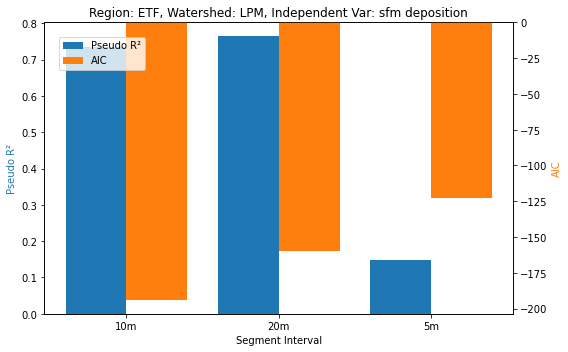

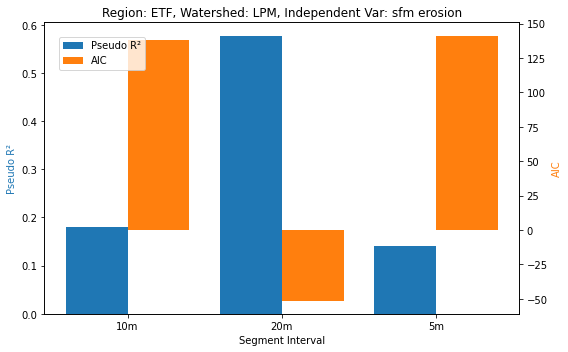

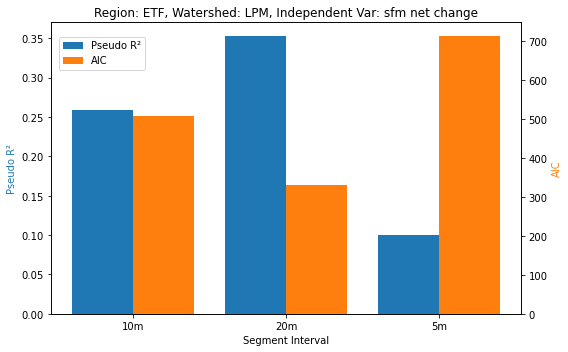

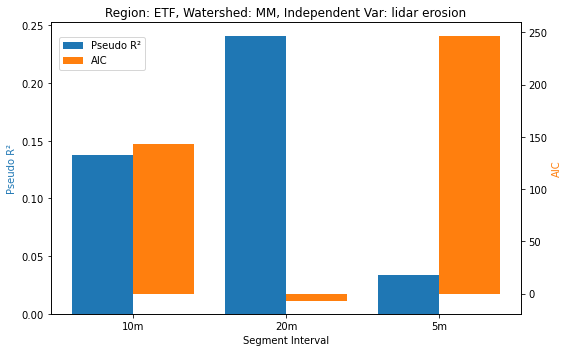

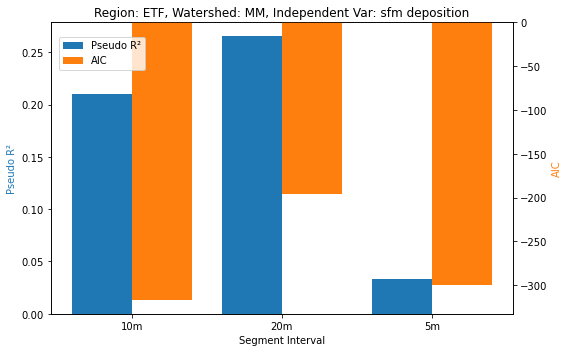

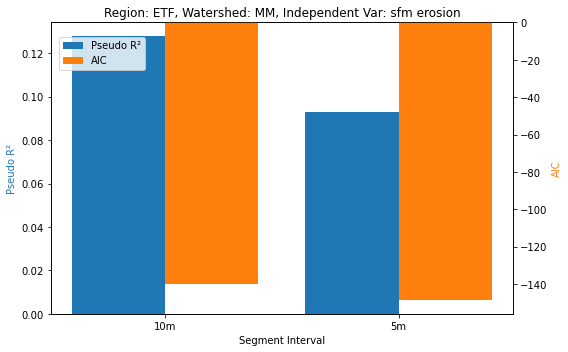

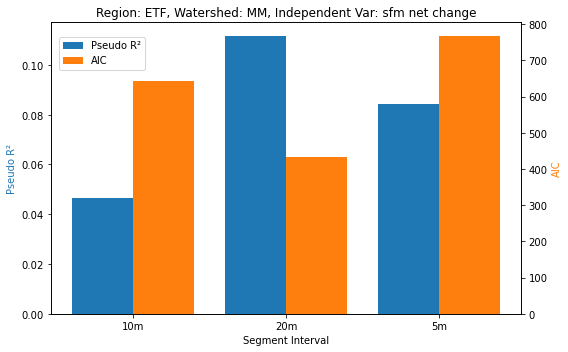

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
csv_file = r"Results Summary\glance_summary.csv"

def create_bar_charts(csv_path):
    # Read CSV
    df = pd.read_csv(csv_path)

    # We will group by Region, Watershed, and independent variable
    group_cols = ["Region", "Watershed", "independent variable"]
    
    for (region, watershed, ind_var), group_df in df.groupby(group_cols):
        # Sort the group by Segment Interval to have a consistent x-axis order
        # (If segment intervals are strings like "5m", "10m", you can parse them or rely on the order they appear.)
        # Here, we assume they are strings that can be sorted naturally, but you can adapt as needed:
        group_df = group_df.sort_values("Segment Interval")
        
        # Extract the segment intervals, pseudo.r.squared, and AIC
        x_labels = group_df["Segment Interval"].tolist()
        pseudo_r2 = group_df["pseudo.r.squared"].tolist()
        aic_vals = group_df["AIC"].tolist()

        # Create the figure and two y-axes
        fig, ax1 = plt.subplots(figsize=(8, 5))
        ax2 = ax1.twinx()

        # Create a position index for each segment interval
        x = np.arange(len(x_labels))
        width = 0.4

        # Bar for pseudo.r.squared on ax1 (left axis)
        ax1.bar(x - width/2, pseudo_r2, width=width, color="tab:blue", label="Pseudo R²")

        # Bar for AIC on ax2 (right axis)
        ax2.bar(x + width/2, aic_vals, width=width, color="tab:orange", label="AIC")

        # Set x-ticks and labels
        ax1.set_xticks(x)
        ax1.set_xticklabels(x_labels)

        # Label the axes
        ax1.set_ylabel("Pseudo R²", color="tab:blue")
        ax2.set_ylabel("AIC", color="tab:orange")
        ax1.set_xlabel("Segment Interval")

        # Add a title that describes the group
        plt.title(f"Region: {region}, Watershed: {watershed}, Independent Var: {ind_var}")

        # Optionally add a legend
        # (We place the legend outside the plot to avoid overlap)
        fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))

        # Tight layout for better spacing
        plt.tight_layout()

        # Save the figure using the group fields in the filename
        safe_region = region.replace("/", "_")
        safe_watershed = watershed.replace("/", "_")
        safe_ind_var = ind_var.replace("/", "_")
        out_name = f"AIC-r2_{safe_region}_{safe_watershed}_{safe_ind_var}.png"
        out_folder = r"Results Summary\Model Diagnostic Plots"
        os.makedirs(out_folder, exist_ok=True)  # Ensure the output folder exists
        out_file = os.path.join(out_folder, out_name)
        plt.savefig(out_file, dpi=300)
        plt.show()
        # Close the figure to free memory if looping over many groups
        plt.close(fig)

create_bar_charts(csv_file)
